# Sentiment Analysis - Review DG by Bankaltimtara
Pipeline: scraping -> cleaning -> labeling -> feature engineering (TF-IDF vs Sentence Transformer) -> modeling -> tuning -> evaluasi


## 1. Install & Import Library

In [ ]:
!pip install google-play-scraper sentence-transformers scikit-learn xgboost pandas -q

In [ ]:
!pip install wordcloud -q

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google_play_scraper import reviews, Sort
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

## 2. Scraping Data Review
Menggunakan loop dengan `continuation_token` supaya scraping tidak berhenti di batch pertama. Catatan: Google Play API membatasi jumlah review yang bisa diambil (biasanya beberapa ribu review terbaru), jadi jumlah akhir bisa lebih kecil dari `max_count` yang diminta - ini limitasi dari sisi Google, bukan bug di kode.

In [ ]:
def scrape_all(app_id, sort_type=Sort.NEWEST, max_count=10000):
    all_reviews = []
    continuation_token = None
    while len(all_reviews) < max_count:
        result, continuation_token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=sort_type,
            count=200,
            continuation_token=continuation_token
        )
        if not result:
            break
        all_reviews.extend(result)
        print(f"Total terkumpul: {len(all_reviews)}")
        if continuation_token is None:
            break
    return all_reviews

raw_reviews = scrape_all('com.lst.Kaltimtara', max_count=10000)

df = pd.DataFrame(raw_reviews)
df.to_csv('review_dg_bankaltimtara.csv', index=False)

print(df.shape)
df.head()

Total terkumpul: 200
Total terkumpul: 400
Total terkumpul: 600
Total terkumpul: 800
Total terkumpul: 1000
Total terkumpul: 1200
Total terkumpul: 1400
Total terkumpul: 1600
Total terkumpul: 1800
Total terkumpul: 2000
Total terkumpul: 2200
Total terkumpul: 2400
Total terkumpul: 2600
Total terkumpul: 2800
Total terkumpul: 2825
(2825, 11)


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4ce6b53e-5e9c-4448-97f3-ebbc66edd670,Arif Rahman,https://play-lh.googleusercontent.com/a-/ALV-UjWoVEnWIPDbYwge0KbbkQ6-qX4eauJ3kVVD1GdGVLrxMFFrHakY,kenapa sudah beberapa hari ini dg saya sedang dalam pemeliharaan terus ya gak bisa di pkai transaksi sama skali,3,0,None,2026-07-05 11:29:54,Mohon maaf atas kendala dan ketidaknyamannya. Kritik dan saran dari Kakak akan menjadi masukan yang berharga untuk menjadikan Bankaltimtara dalam mengembangkan aplikasi kedepannya agar menjadi lebih baik serta aman dalam bertransaksi kapan dan dimanapun nasabah berada. Terima kasih Kakak telah menjadi nasabah setia Bankaltimtara. Terima kasih_Her.,2026-07-05 13:59:44,None
1,4b653c60-15f9-4ab5-8ef7-63bd3a9c387d,Taupik Ramdani,https://play-lh.googleusercontent.com/a-/ALV-UjWC9Pmb-1QDpdKDt7L-WXuOo16OMnNhY9sCHbLahtBPRukdBuE,"Akhir-akhir ini sering sekali ""dalam pemeliharaan"", bahkan hari ini hampir tidak bisa digunakan sama sekali karena ""Pemeliharaan"". Tolong dicantumkan kisaran waktu ""Pemeliharaan"" dan dioptimalkan app nya.",4,0,3.2.2,2026-07-05 11:20:33,Mohon maaf atas kendala dan ketidaknyamannya. Kritik dan saran dari Kakak akan menjadi masukan yang berharga untuk menjadikan Bankaltimtara dalam mengembangkan aplikasi kedepannya agar menjadi lebih baik serta aman dalam bertransaksi kapan dan dimanapun nasabah berada. Terima kasih Kakak telah menjadi nasabah setia Bankaltimtara. Terima kasih_Her.,2026-07-05 13:59:30,3.2.2
2,6716f033-8ac7-4cfd-9d33-23576976e83b,Norma Abdul Waris,https://play-lh.googleusercontent.com/a-/ALV-UjUo-DMQ5SAr4ZPbDW8A3wwFQeC2WjpOAKQJSOPLMgHq8j5tDVanog,"hmmm sll bermasalah, skrng mau transaksi pun sedang dlm pemeliharaan, bkn mempermudah malah nambah ssh tolong d perbaiki",3,0,3.2.2,2026-07-01 08:19:42,Mohon maaf atas kendala dan ketidaknyamannya. Kritik dan saran dari Kakak akan menjadi masukan yang berharga untuk menjadikan Bankaltimtara dalam mengembangkan aplikasi kedepannya agar menjadi lebih baik serta aman dalam bertransaksi kapan dan dimanapun nasabah berada. Terima kasih Kakak telah menjadi nasabah setia Bankaltimtara. Terima kasih_Len,2026-07-01 10:50:13,3.2.2
3,5be38b75-a3e8-4e83-b817-d7442928d43e,kezia Grace,https://play-lh.googleusercontent.com/a-/ALV-UjWrdSD6fKErUN7HLqvujQnpwX9P2GBMYHZbJ9DiL7yp4HJhXg3O,"heran dehhh qris suka gabisaa tf pun seringgg gabisa, banyak banget gangguan orang kdg butuh buat transaksi malah dikit dikit error dikit dikit gagal tolong deh yaa",2,0,3.2.2,2026-06-30 10:03:57,"Mohon maaf atas hal yang terjadi ya Kak, silakan menghubungi layanan Bankaltimtara Call Center kami dinomor telepon 1500124, dengan senang hati petugas kami akan membantu terkait kendala yang dialami. Kami akan terus melakukan pengembangan demi kepuasan Nasabah Bankaltimtara. Terimakasih telah menjadi Nasabah Setia Bankaltimtara. Terima kasih_Len",2026-06-30 11:57:16,3.2.2
4,50d40332-5e17-4958-a7b9-4d9db42a7972,Bahrul Bahrul,https://play-lh.googleusercontent.com/a/ACg8ocJtFD457phIi0tUpNH79HjhBceFkzJi-Z2D--HZN4-m6xyy1A=mo,APLIKASI BONTOK AKTIFASI AKU HJE NADE MAU. HANDEK NYAMAN MALAH MOLAH PAYAH MANA LAGI DAFTARNYA HARUS MAKAI MATERAI 10000 ANTRINYA LAWAS HAK PULANG. PUKI MAKNYA DG NI!,1,0,3.2.2,2026-06-26 12:15:35,"Mohon maaf atas hal yang terjadi ya Kak, silakan menghubungi layanan Bankaltimtara Call Center kami dinomor telepon 1500124, dengan senang hati petugas kami akan membantu terkait kendala yang dialami. Kami akan terus melakukan pengembangan demi kepuasan Nasabah Bankaltimtara. Terimakasih telah menjadi Nasabah Setia Bankaltimtara. Terima kasih_Msr",2026-06-26 13:00:38,3.2.2


## 3. Data Cleaning
Hapus kolom tidak relevan, cek missing value, hapus baris kosong & duplikat.

In [ ]:
df.drop(['reviewId', 'userName', 'userImage'], axis=1, inplace=True)

df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2825 entries, 0 to 2824
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   content               2825 non-null   object        
 1   score                 2825 non-null   int64         
 2   thumbsUpCount         2825 non-null   int64         
 3   reviewCreatedVersion  2344 non-null   object        
 4   at                    2825 non-null   datetime64[ns]
 5   replyContent          2825 non-null   object        
 6   repliedAt             2825 non-null   datetime64[ns]
 7   appVersion            2344 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 176.7+ KB
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion    481
at                        0
replyContent              0
repliedAt                 0
appVersion              481
dtype: int64


In [ ]:
df = df.dropna().reset_index(drop=True)

print('Jumlah baris duplikat:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

df.info()
print(df.shape)
df['score'].value_counts()

Jumlah baris duplikat: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2344 entries, 0 to 2343
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   content               2344 non-null   object        
 1   score                 2344 non-null   int64         
 2   thumbsUpCount         2344 non-null   int64         
 3   reviewCreatedVersion  2344 non-null   object        
 4   at                    2344 non-null   datetime64[ns]
 5   replyContent          2344 non-null   object        
 6   repliedAt             2344 non-null   datetime64[ns]
 7   appVersion            2344 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 146.6+ KB
(2344, 8)


,count
score,
1,1000
5,745
2,243
3,226
4,130


## 4. Labeling Sentiment dari Score
Rating 1-2 = negatif, 3 = netral, 4-5 = positif (proxy label).

In [ ]:
def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['sentiment'] = df['score'].apply(label_sentiment)
df['sentiment'].value_counts()

,count
sentiment,
negatif,1243
positif,875
netral,226


## 4b. Buang Kelas Netral (Binary Classification)
Berdasarkan pengecekan manual, review dengan score 3 (dilabel netral) ternyata banyak berisi komplain jelas (bug, error, tidak bisa login) - proxy label dari score tidak reliable untuk kelas ini. Karena itu, kelas netral dibuang dan project difokuskan ke klasifikasi biner (negatif vs positif).

In [ ]:
df = df[df['sentiment'] != 'netral'].copy().reset_index(drop=True)
print(df['sentiment'].value_counts())

sentiment
negatif    1243
positif     875
Name: count, dtype: int64


## 5. Text Cleaning

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)          # hapus URL
    text = re.sub(r'[^a-zA-Z\s]', '', text)       # hapus angka & simbol/emoji
    text = re.sub(r'\s+', ' ', text).strip()      # hapus spasi berlebih
    return text

df['content_clean'] = df['content'].apply(clean_text)
df[['content', 'content_clean']].sample(5)

,content,content_clean
1893,"Sangat terbantu dengan keberadaan dg by bankaltimtara yang baru, memudahkan utk transaksi terutama pembelian pulsa dan token listrik, sukses terus Bankaltimtara",sangat terbantu dengan keberadaan dg by bankaltimtara yang baru memudahkan utk transaksi terutama pembelian pulsa dan token listrik sukses terus bankaltimtara
449,gangguan trus,gangguan trus
335,"Aplikasi Cacat !!!!! kalau aplikasi belum sempurna itu jangan menaikan versi nya. Dengan banyaknya pembaruan pada aplikasi seharusnya bisa lebih bagus dri yg sebelumnya, ini malah makin cacat !!!! Contoh juga, Tidak bisa menarik uang dengan metode cardless di ATM jika ATM tersebut kehabisan kertas struk. Kan CACAT Namanya.",aplikasi cacat kalau aplikasi belum sempurna itu jangan menaikan versi nya dengan banyaknya pembaruan pada aplikasi seharusnya bisa lebih bagus dri yg sebelumnya ini malah makin cacat contoh juga tidak bisa menarik uang dengan metode cardless di atm jika atm tersebut kehabisan kertas struk kan cacat namanya
24,Sangat membantu kehidupan sehari-hari,sangat membantu kehidupan seharihari
1327,Ribet amat di perbarui malah ndk bisa msuk hrus kh buang2 waktu lg ke bank buat aktifkan lg,ribet amat di perbarui malah ndk bisa msuk hrus kh buang waktu lg ke bank buat aktifkan lg


## 6. Split Label (dipakai bersama oleh kedua representasi fitur)

In [ ]:
y = df['sentiment']

le = LabelEncoder()
y_enc_full = le.fit_transform(y)
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'negatif': np.int64(0), 'positif': np.int64(1)}


## 7A. Feature Engineering - Sentence Transformer
Encode dilakukan sebelum split (model pretrained, tidak fit ke data ini, jadi tidak ada data leakage).

In [ ]:
st_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

X_st = st_model.encode(
    df['content_clean'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

X_train_st, X_test_st, y_train, y_test = train_test_split(
    X_st, y, test_size=0.2, random_state=42, stratify=y
)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print(X_st.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

(2118, 384)


## 7B. Feature Engineering - TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['content_clean'])

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(X_tfidf.shape)

(2118, 5000)


## 8A. Modeling - Sentence Transformer

In [ ]:
models_st = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results_st = {}
for name, m in models_st.items():
    m.fit(X_train_st, y_train)
    pred = m.predict(X_test_st)
    print(f"--- {name} (Sentence Transformer) ---")
    print(classification_report(y_test, pred, zero_division=0))
    results_st[name] = pred

xgb_st = XGBClassifier()
xgb_st.fit(X_train_st, y_train_enc)
pred_xgb_st = xgb_st.predict(X_test_st)
print("--- XGBoost (Sentence Transformer) ---")
print(classification_report(y_test_enc, pred_xgb_st, target_names=le.classes_, zero_division=0))

--- Logistic Regression (Sentence Transformer) ---
              precision    recall  f1-score   support

     negatif       0.85      0.93      0.89       249
     positif       0.88      0.76      0.82       175

    accuracy                           0.86       424
   macro avg       0.86      0.84      0.85       424
weighted avg       0.86      0.86      0.86       424

--- Random Forest (Sentence Transformer) ---
              precision    recall  f1-score   support

     negatif       0.84      0.95      0.89       249
     positif       0.92      0.74      0.82       175

    accuracy                           0.87       424
   macro avg       0.88      0.85      0.86       424
weighted avg       0.87      0.87      0.86       424

--- XGBoost (Sentence Transformer) ---
              precision    recall  f1-score   support

     negatif       0.85      0.92      0.88       249
     positif       0.88      0.76      0.81       175

    accuracy                           0.86    

## 8B. Modeling - TF-IDF

In [ ]:
models_tf = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results_tf = {}
for name, m in models_tf.items():
    m.fit(X_train_tf, y_train_tf)
    pred = m.predict(X_test_tf)
    print(f"--- {name} (TF-IDF) ---")
    print(classification_report(y_test_tf, pred, zero_division=0))
    results_tf[name] = pred

y_train_tf_enc = le.transform(y_train_tf)
y_test_tf_enc = le.transform(y_test_tf)

xgb_tf = XGBClassifier()
xgb_tf.fit(X_train_tf, y_train_tf_enc)
pred_xgb_tf = xgb_tf.predict(X_test_tf)
print("--- XGBoost (TF-IDF) ---")
print(classification_report(y_test_tf_enc, pred_xgb_tf, target_names=le.classes_, zero_division=0))

--- Logistic Regression (TF-IDF) ---
              precision    recall  f1-score   support

     negatif       0.83      0.98      0.90       249
     positif       0.95      0.72      0.82       175

    accuracy                           0.87       424
   macro avg       0.89      0.85      0.86       424
weighted avg       0.88      0.87      0.87       424

--- Random Forest (TF-IDF) ---
              precision    recall  f1-score   support

     negatif       0.82      0.96      0.88       249
     positif       0.92      0.70      0.80       175

    accuracy                           0.85       424
   macro avg       0.87      0.83      0.84       424
weighted avg       0.86      0.85      0.85       424

--- XGBoost (TF-IDF) ---
              precision    recall  f1-score   support

     negatif       0.85      0.91      0.88       249
     positif       0.86      0.77      0.81       175

    accuracy                           0.85       424
   macro avg       0.86      0.84  

## 9. Hyperparameter Tuning (TF-IDF + Logistic Regression - kombinasi terbaik)
Berdasarkan perbandingan di atas, TF-IDF + Logistic Regression memberi hasil terbaik. Tuning difokuskan pada kombinasi ini.

In [ ]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train_tf, y_train_tf)

print("Best params:", grid_lr.best_params_)
print("Best CV f1_macro score:", grid_lr.best_score_)

best_lr_tf = grid_lr.best_estimator_
pred_best_lr_tf = best_lr_tf.predict(X_test_tf)

print("--- Logistic Regression (TF-IDF, tuned) ---")
print(classification_report(y_test_tf, pred_best_lr_tf, zero_division=0))

Best params: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV f1_macro score: 0.8723782166422172
--- Logistic Regression (TF-IDF, tuned) ---
              precision    recall  f1-score   support

     negatif       0.86      0.93      0.89       249
     positif       0.89      0.78      0.83       175

    accuracy                           0.87       424
   macro avg       0.87      0.86      0.86       424
weighted avg       0.87      0.87      0.87       424



## 10. Error Analysis
Melihat review mana saja yang salah diprediksi oleh model terbaik, untuk memahami pola kesalahan.

In [ ]:
df_test_tf = df.loc[y_test_tf.index].copy()
df_test_tf['predicted'] = pred_best_lr_tf

salah = df_test_tf[df_test_tf['sentiment'] != df_test_tf['predicted']]
print(f"Jumlah salah prediksi: {len(salah)} dari {len(df_test_tf)}")

pd.set_option('display.max_colwidth', None)
salah[['content', 'sentiment', 'predicted']].head(20)

Jumlah salah prediksi: 55 dari 424


,content,sentiment,predicted
476,"Lebih enak DG lama, yg baru ini agak ribet dan nggak bagus",negatif,positif
238,kenapa saat ini dg tdak bisa di buka SMA Skali,positif,negatif
705,"Semua nya udh bagus, tp knp sih admin nya klo tf ke rekening bank lain mahal. sekali tf aja 6500. masukan aja sih tolong bwt admin nya dikurangin lagi, soalnya aq sering bgt tf udh brp itu terpotong",positif,negatif
2062,Masih banyak harus perbaikannya username gk bisa dipakai padahal itu itu juga yg dipakainya aneh,positif,negatif
1728,"Gimana cara mau daftar, kode frevikasix dpat dri mna.. Langsung mnta di masukin",positif,negatif
297,banyak bug. seperti mutasi kadang tidak muncul,negatif,positif
1456,Maff bertanya dapat kode registrasinya dari mana ya🙏🏼,positif,negatif
1717,"Saya sudah menggunakan aplikasi ini selama 2 bulan sangat membantu,namun saat melakukan penarikan cardless ,saat mencoba melakukan transaksi tanpa kartu di tempat yg berbeda-beda, malah yg muncul Pembayaran PPB, Pulsa ,dan Handphone ,tolong penjelasannya",positif,negatif
2044,Mau aktivasi saja sulitnya minta ampun tolong dikembangkan lagi aplikasinya agar lebih mudah dipakai,negatif,positif
245,"tolong percepat perbaikannya dong, masa eror gk bisa buka apl, cuma logo aja yg terpampang",positif,negatif


## 11. Confusion Matrix (Model Terbaik: TF-IDF + Logistic Regression tuned)

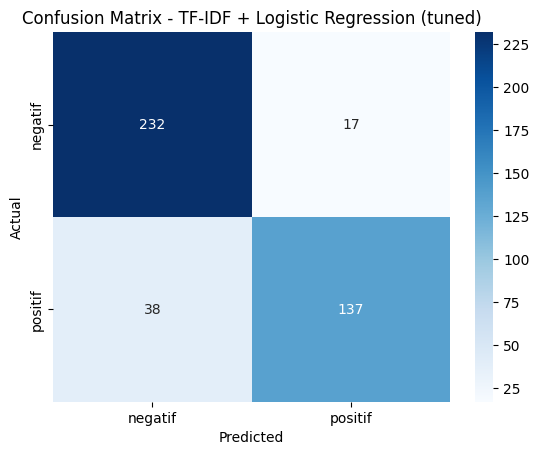

In [ ]:
cm = confusion_matrix(y_test_tf, pred_best_lr_tf, labels=best_lr_tf.classes_)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=best_lr_tf.classes_,
            yticklabels=best_lr_tf.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF + Logistic Regression (tuned)')
plt.show()

## 12. Word Cloud per Sentiment
Visualisasi kata yang paling sering muncul di review positif vs negatif.

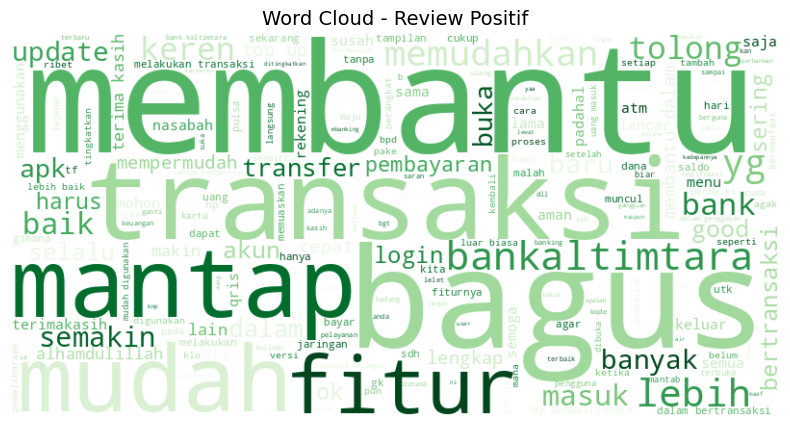

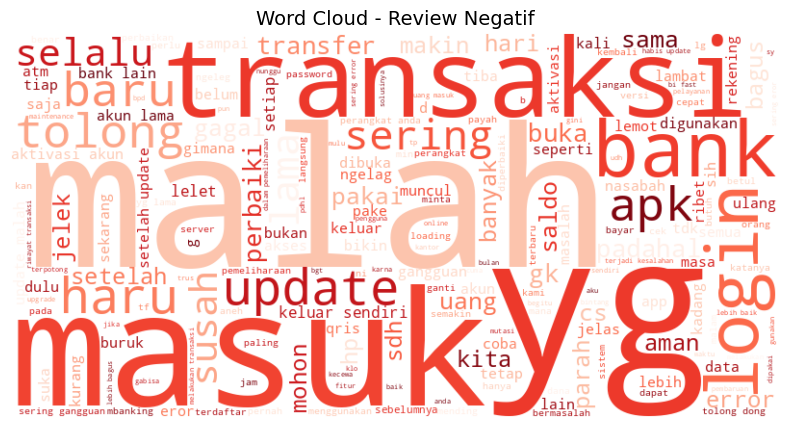

In [ ]:
stopwords_id = set([
    'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'dan', 'atau', 'untuk', 'dengan',
    'saya', 'aplikasi', 'aplikasinya', 'nya', 'ada', 'tidak', 'gak', 'ga', 'nggak',
    'kalau', 'kalo', 'jadi', 'juga', 'sudah', 'udah', 'saat', 'kok', 'ya', 'lah',
    'aja', 'karena', 'bisa', 'akan', 'nih', 'dg', 'dgn', 'pas', 'buat', 'lagi',
    'tapi', 'sangat', 'banget', 'terus', 'kenapa', 'apa', 'mau', 'sekali', 'masih'
])

def plot_wordcloud(text_series, title, color):
    text = ' '.join(text_series)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stopwords_id,
        colormap=color
    ).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.show()

plot_wordcloud(df[df['sentiment']=='positif']['content_clean'], 'Word Cloud - Review Positif', 'Greens')
plot_wordcloud(df[df['sentiment']=='negatif']['content_clean'], 'Word Cloud - Review Negatif', 'Reds')

## 13. Kata & Frasa Paling Sering Muncul di Review Negatif
Menggunakan hasil TF-IDF untuk melihat kata/frasa (unigram & bigram) yang paling khas muncul di review negatif - ini membantu mengidentifikasi masalah paling umum yang dialami pengguna.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(text_series, n=20, ngram_range=(1,2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=list(stopwords_id), max_features=5000)
    bow = vec.fit_transform(text_series)
    freq = bow.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    top_idx = freq.argsort()[::-1][:n]
    return pd.DataFrame({'term': terms[top_idx], 'count': freq[top_idx]})

top_negatif = top_ngrams(df[df['sentiment']=='negatif']['content_clean'], n=20)
print('Top 20 kata/frasa di review NEGATIF:')
top_negatif

Top 20 kata/frasa di review NEGATIF:


,term,count
0,malah,271
1,update,231
2,yg,225
3,bank,224
4,transaksi,213
5,sering,196
6,masuk,191
7,lama,176
8,tolong,160
9,login,137


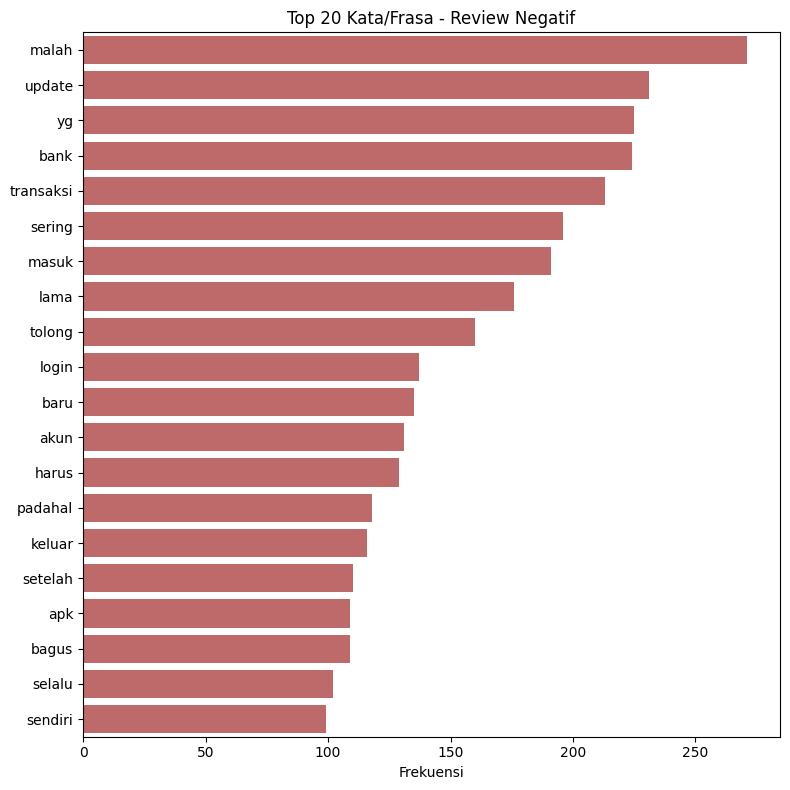

In [ ]:
plt.figure(figsize=(8, 8))
sns.barplot(data=top_negatif, x='count', y='term', color='indianred')
plt.title('Top 20 Kata/Frasa - Review Negatif')
plt.xlabel('Frekuensi')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 14. Kategorisasi Masalah (Rule-based Keyword Grouping)
Mengelompokkan komplain ke beberapa kategori masalah umum (login/OTP, error/bug, transaksi/transfer, performa lambat, tampilan/UI) berdasarkan kata kunci. Ini pendekatan sederhana (bukan topic modeling formal seperti LDA), tapi cukup untuk memberi gambaran cepat masalah mana yang paling sering dikeluhkan.

               kategori  jumlah
0               Lainnya     447
1    Transaksi/Transfer     335
2       Performa Lambat     310
3  Login/OTP/Registrasi     230
4       Error/Bug/Crash     143
5           Tampilan/UI     111


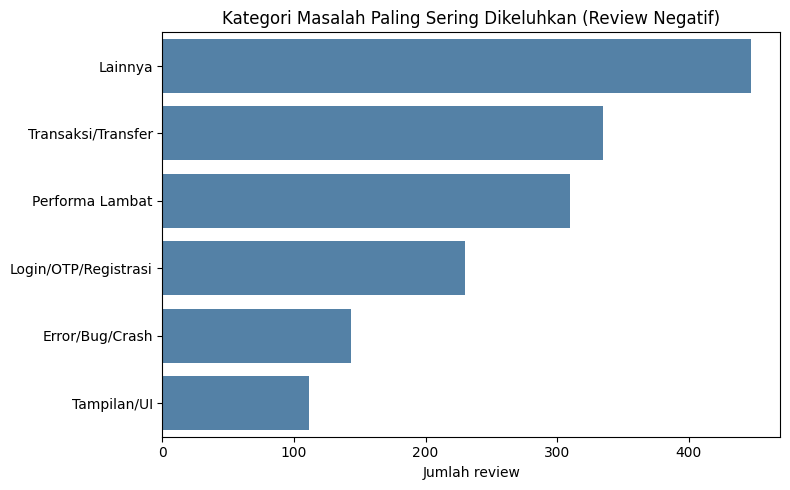

In [ ]:
kategori_keywords = {
    'Login/OTP/Registrasi': ['login', 'log in', 'otp', 'registrasi', 'daftar', 'aktivasi', 'kode'],
    'Error/Bug/Crash': ['error', 'bug', 'force close', 'ke stuck', 'stuck', 'gagal terus', 'tidak bisa dibuka', 'tidak bisa terbuka'],
    'Transaksi/Transfer': ['transfer', 'transaksi', 'saldo', 'gagal transfer', 'pembayaran', 'topup', 'top up'],
    'Performa Lambat': ['lambat', 'lemot', 'lag', 'loading lama', 'loading'],
    'Tampilan/UI': ['tampilan', 'ribet', 'susah dipakai', 'membingungkan', 'ui'],
}

def kategorikan(text):
    found = []
    for kategori, kw_list in kategori_keywords.items():
        if any(kw in text for kw in kw_list):
            found.append(kategori)
    return found if found else ['Lainnya']

df_negatif = df[df['sentiment']=='negatif'].copy()
df_negatif['kategori_masalah'] = df_negatif['content_clean'].apply(kategorikan)

from collections import Counter
all_kategori = [k for sublist in df_negatif['kategori_masalah'] for k in sublist]
kategori_count = pd.DataFrame(Counter(all_kategori).most_common(), columns=['kategori', 'jumlah'])

print(kategori_count)

plt.figure(figsize=(8, 5))
sns.barplot(data=kategori_count, x='jumlah', y='kategori', color='steelblue')
plt.title('Kategori Masalah Paling Sering Dikeluhkan (Review Negatif)')
plt.xlabel('Jumlah review')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
kategori_terbanyak = kategori_count.iloc[0]['kategori']
print(f"Contoh review kategori '{kategori_terbanyak}':\n")

contoh = df_negatif[df_negatif['kategori_masalah'].apply(lambda x: kategori_terbanyak in x)]['content']
for i, r in enumerate(contoh.sample(min(10, len(contoh)), random_state=42), 1):
    print(f"{i}. {r}\n")

Contoh review kategori 'Lainnya':

1. Kenapa perangkat tidak aman ,, Aduh DG Sekarang jeleknya Bah

2. Aplikasi cacat ya di pakek,masak eror pas tiap tgl satu,waktu gajian aplikasi eror trusss tolong di perbaiki.nti kalok udh ada perubahan saya bintang lima sementar satu dulu trimakasih

3. bank paling ga rekomendasi... aplikasinya sering ganguan atm sering kosong pelayanan buruk. saran jangan pernah menyimpan uang anda di dalam di saat anda butuh pasti ganguan. bank nga jelas

4. sering kali tidak bisa di buka.. entah karna apa🤔

5. aplikasi bermanfaat, tapi alangkah baiknya kalian cek tarif paket data yg diberikan provider kartu pra bayar harusnya detail berapa Giga byte yg didapat dari harga yg dibeli. Masa 55 ribu, tapi GB nya tidak dicantumkan. setelah dibeli ternyata dapatnya cuma 5 GB, keterlaluan.

6. maintenance dari pagi jam 9:00 wita sampai 17:37 WITA, ATM dr tempat tinggal paling dekat 2 / 3 kilo, h-4 lebaran pasti banyak kebutuhan dan kegunaan tapi enggak bisa diandalkan s

In [ ]:
kategori_keywords = {
    'Login/OTP/Registrasi': ['login', 'log in', 'otp', 'registrasi', 'daftar', 'aktivasi', 'kode'],
    'Error/Bug/Crash': ['error', 'bug', 'force close', 'stuck', 'gagal terus', 'tidak bisa dibuka', 'tidak bisa terbuka'],
    'Transaksi/Transfer': ['transfer', 'transaksi', 'saldo', 'gagal transfer', 'pembayaran', 'topup', 'top up'],
    'Performa Lambat': ['lambat', 'lemot', 'lag', 'loading lama', 'loading'],
    'Tampilan/UI': ['tampilan', 'ribet', 'susah dipakai', 'membingungkan', 'ui'],
}

def kategorikan(text):
    found = []
    for kategori, kw_list in kategori_keywords.items():
        if any(kw in text for kw in kw_list):
            found.append(kategori)
    return found if found else ['Lainnya']

df_negatif = df[df['sentiment']=='negatif'].copy()
df_negatif['kategori_masalah'] = df_negatif['content_clean'].apply(kategorikan)

from collections import Counter
all_kategori = [k for sublist in df_negatif['kategori_masalah'] for k in sublist]
kategori_count = pd.DataFrame(Counter(all_kategori).most_common(), columns=['kategori', 'jumlah'])
print(kategori_count)

               kategori  jumlah
0               Lainnya     447
1    Transaksi/Transfer     335
2       Performa Lambat     310
3  Login/OTP/Registrasi     230
4       Error/Bug/Crash     143
5           Tampilan/UI     111


In [ ]:
vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words=list(stopwords_id))
dtm = vectorizer.fit_transform(df[df['sentiment']=='negatif']['content_clean'])

n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Topic {idx+1}: {', '.join(top_words)}")

Topic 1: malah, transaksi, sendiri, sering, keluar, update, error, tolong, makin, perbaiki
Topic 2: akun, bank, harus, login, cs, update, malah, aktivasi, lama, padahal
Topic 3: banyak, sering, eror, mohon, tolong, gagal, diperbaiki, transaksi, bank, masuk
Topic 4: aman, anda, perangkat, hari, pemeliharaan, dalam, transaksi, uang, dibuka, tolong
Topic 5: yg, malah, update, masuk, baru, bank, versi, lama, apk, bagus
